# Practical Statistics for Data Scientists
## Chapter 3 — Statistical Experiments and Significance Testing

**Code Reproduction + Theoretical Deep-Dive**

### Tujuan Pembelajaran

Chapter 3 membahas bagaimana eksperimen dirancang untuk menguji hipotesis dan bagaimana hasil eksperimen dievaluasi secara statistik. Topik ini sangat relevan bagi data scientist karena banyak keputusan produk, marketing, UI, dan sistem digital dibuat melalui eksperimen terkontrol.

Alur utama chapter adalah:

**Experiment → Hypothesis → Resampling/Test Statistic → p-value → Decision → Practical Interpretation**

Notebook ini mengikuti struktur Chapter 3 pada *Practical Statistics for Data Scientists, 2nd Edition*, tetapi kode ditulis ulang dan visualisasi diperjelas dengan anotasi, warna bermakna, dan interpretasi di bawah setiap chart.

## 1. Import Library dan Konfigurasi

`numpy` digunakan untuk simulasi, `pandas` untuk tabel data, `matplotlib` untuk visualisasi, dan `scipy.stats` untuk statistical tests.

Random seed digunakan agar simulasi dapat direproduksi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

np.random.seed(42)
rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

print("Library berhasil dimuat.")

Library berhasil dimuat.


## 2. A/B Testing

**A/B testing** adalah eksperimen terkontrol yang membandingkan dua versi perlakuan terhadap outcome tertentu.

- **Control (A)**: kondisi baseline atau kondisi yang sedang digunakan.
- **Treatment (B)**: versi baru yang ingin diuji.

Ide dasarnya adalah mengalokasikan unit secara acak sehingga perbedaan outcome antara A dan B dapat lebih masuk akal diatribusikan pada treatment, bukan pada perbedaan karakteristik awal kelompok.

Dalam data science, outcome dapat berupa conversion rate, revenue, click-through rate, session duration, error rate, atau metrik lain yang relevan.

In [2]:
# Simulasi eksperimen A/B: conversion rate
n_A = 5000
n_B = 5000

conversion_A = rng.binomial(1, 0.100, n_A)
conversion_B = rng.binomial(1, 0.115, n_B)

ab = pd.DataFrame({
    "Group": ["Control (A)", "Treatment (B)"],
    "Users": [n_A, n_B],
    "Conversions": [conversion_A.sum(), conversion_B.sum()],
})

ab["Conversion Rate"] = ab["Conversions"] / ab["Users"]

display(ab)

,Group,Users,Conversions,Conversion Rate
0,Control (A),5000,493,0.0986
1,Treatment (B),5000,559,0.1118


### Visualisasi 1 — Conversion Rate: Control vs Treatment

Pada chart ini, **biru** digunakan untuk control dan **hijau** untuk treatment. Nilai persentase ditulis langsung di atas bar sehingga pembaca tidak harus menebak nilai dari sumbu.

Perbedaan absolut conversion rate disebut **lift in percentage points**, sedangkan relative lift membandingkan peningkatan terhadap baseline.

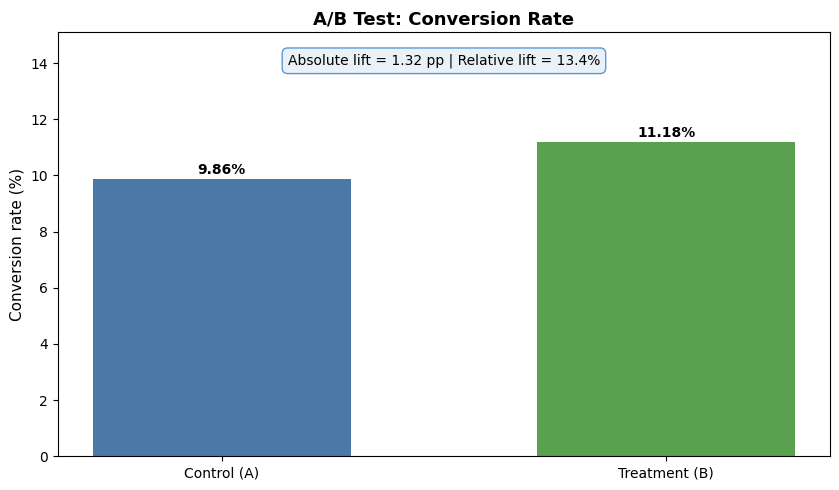

In [3]:
rate_A = ab.loc[0, "Conversion Rate"]
rate_B = ab.loc[1, "Conversion Rate"]
diff = rate_B - rate_A
relative_lift = diff / rate_A

fig, ax = plt.subplots(figsize=(8.5, 5))
colors = ["#4C78A8", "#59A14F"]
bars = ax.bar(ab["Group"], ab["Conversion Rate"] * 100, color=colors, width=0.58)

ax.set_title("A/B Test: Conversion Rate")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, max(ab["Conversion Rate"] * 100) * 1.35)

for bar, val in zip(bars, ab["Conversion Rate"] * 100):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{val:.2f}%",
        ha="center",
        fontweight="bold"
    )

ax.text(
    0.5, 0.95,
    f"Absolute lift = {diff*100:.2f} pp | Relative lift = {relative_lift*100:.1f}%",
    transform=ax.transAxes,
    ha="center",
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#EAF2F8", edgecolor="#5B9BD5")
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Treatment B memiliki conversion rate yang lebih tinggi pada simulasi ini. Namun, perbedaan deskriptif belum membuktikan bahwa treatment benar-benar menghasilkan perbedaan pada population. Significance testing digunakan untuk mengevaluasi apakah perbedaan tersebut cukup kuat terhadap variasi acak.

## 3. Why Have a Control Group?

Control group berfungsi sebagai baseline untuk mengetahui apa yang kemungkinan terjadi tanpa treatment.

Tanpa control, peningkatan outcome dapat disebabkan oleh banyak faktor lain, misalnya perubahan musim, kampanye marketing lain, perubahan user composition, atau tren waktu.

Random assignment dan control group membantu mengurangi confounding dalam eksperimen.

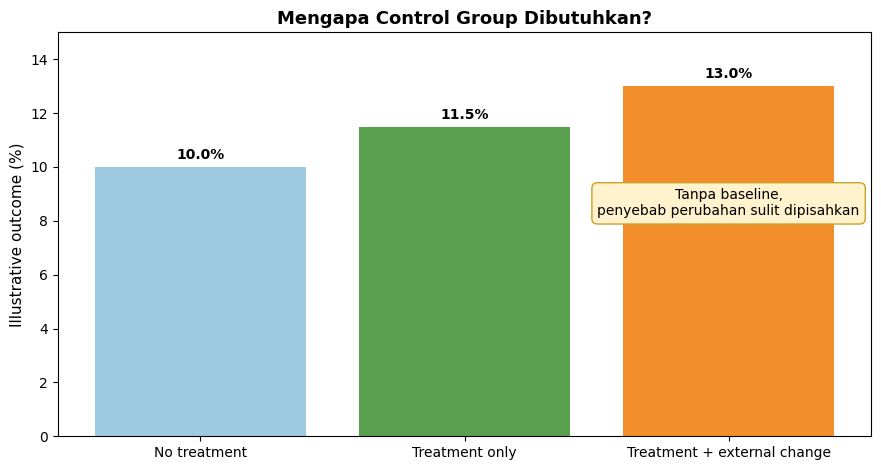

In [4]:
# Ilustrasi tiga skenario: baseline, treatment, dan perubahan eksternal
scenarios = pd.DataFrame({
    "Scenario": [
        "No treatment",
        "Treatment only",
        "Treatment + external change"
    ],
    "Observed rate": [10.0, 11.5, 13.0]
})

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ["#9ECAE1", "#59A14F", "#F28E2B"]
bars = ax.bar(scenarios["Scenario"], scenarios["Observed rate"], color=colors)

ax.set_title("Mengapa Control Group Dibutuhkan?")
ax.set_ylabel("Illustrative outcome (%)")
ax.set_ylim(0, 15)

for bar, value in zip(bars, scenarios["Observed rate"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.text(
    2, 8.2,
    "Tanpa baseline,\npenyebab perubahan sulit dipisahkan",
    ha="center",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF2CC", edgecolor="#C9A227")
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Chart ini bersifat ilustratif untuk menunjukkan fungsi control group. Perubahan outcome tidak selalu berasal dari treatment; external changes dapat terjadi bersamaan. Karena itu, control group memberikan pembanding terhadap kondisi yang terjadi tanpa treatment.

## 4. Why Not C, D, ...?

A/B testing hanya membandingkan dua kondisi, tetapi eksperimen dapat memiliki lebih dari dua arm. Multi-arm experiment memungkinkan beberapa alternatif dibandingkan sekaligus.

Namun, semakin banyak kelompok yang diuji, semakin besar masalah **multiple testing**. Jika banyak hypothesis diuji menggunakan threshold yang sama, peluang mendapatkan setidaknya satu hasil “significant” secara kebetulan meningkat.

Karena itu, desain multi-arm perlu disertai strategi pengendalian error.

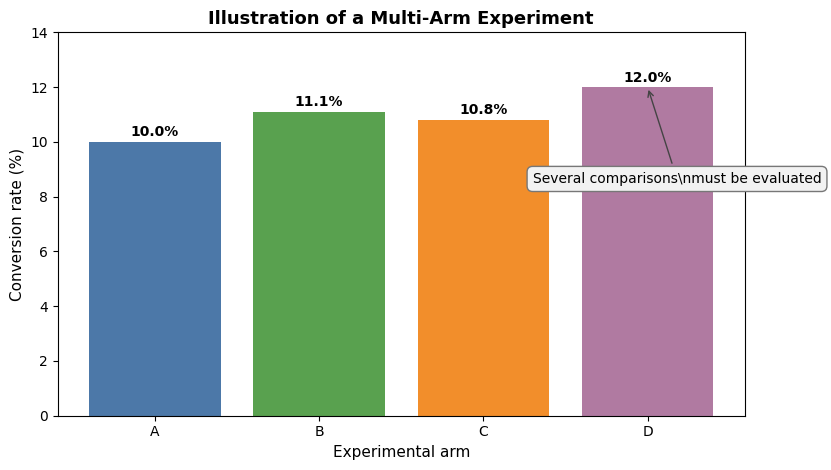

In [5]:
arms = pd.DataFrame({
    "Variant": ["A", "B", "C", "D"],
    "Conversion Rate (%)": [10.0, 11.1, 10.8, 12.0]
})

fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = ["#4C78A8", "#59A14F", "#F28E2B", "#B07AA1"]
bars = ax.bar(arms["Variant"], arms["Conversion Rate (%)"], color=colors)

ax.set_title("Illustration of a Multi-Arm Experiment")
ax.set_xlabel("Experimental arm")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, 14)

for bar, value in zip(bars, arms["Conversion Rate (%)"]):
    ax.text(bar.get_x()+bar.get_width()/2, value+0.2, f"{value:.1f}%", ha="center", fontweight="bold")

ax.annotate(
    "Several comparisons\\nmust be evaluated",
    xy=(3, 12),
    xytext=(2.3, 8.5),
    arrowprops=dict(arrowstyle="->", color="#444444"),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#F2F2F2", edgecolor="#777777")
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Multi-arm experiment dapat membandingkan beberapa alternatif secara paralel, tetapi jumlah pairwise comparisons bertambah. Kondisi ini menjadi alasan penting untuk memahami multiple testing.

## 5. Hypothesis Tests

Hypothesis testing adalah prosedur formal untuk mengevaluasi apakah data memberikan bukti yang cukup terhadap suatu klaim.

Dua komponen utama adalah:

- **Null hypothesis (H₀):** kondisi baseline atau tidak ada efek/perbedaan sesuai parameter yang diuji.
- **Alternative hypothesis (H₁):** terdapat efek/perbedaan yang ingin dideteksi.

Penting untuk membedakan “tidak cukup bukti menolak H₀” dengan “H₀ terbukti benar”. Statistical testing tidak memberikan bukti absolut bahwa H₀ benar.

In [6]:
# Contoh formulasi hipotesis untuk A/B test conversion.
hypothesis_table = pd.DataFrame({
    "Component": ["Null hypothesis (H0)", "Alternative hypothesis (H1)"],
    "Statement": [
        "p_B - p_A = 0",
        "p_B - p_A != 0"
    ],
    "Meaning": [
        "Tidak ada perbedaan conversion rate pada population",
        "Ada perbedaan conversion rate pada population"
    ]
})

display(hypothesis_table)

,Component,Statement,Meaning
0,Null hypothesis (H0),p_B - p_A = 0,Tidak ada perbedaan conversion rate pada popul...
1,Alternative hypothesis (H1),p_B - p_A != 0,Ada perbedaan conversion rate pada population


## 6. One-Way versus Two-Way Hypothesis Tests

**One-way / one-sided test** digunakan ketika arah efek telah ditentukan sebelum analisis, misalnya H₁: pB > pA.

**Two-sided test** digunakan ketika kita hanya ingin mengetahui apakah ada perbedaan, baik treatment lebih tinggi maupun lebih rendah, misalnya H₁: pB ≠ pA.

Pemilihan one-sided atau two-sided harus ditentukan berdasarkan pertanyaan penelitian sebelum melihat hasil, bukan dipilih setelah melihat data untuk mendapatkan p-value yang lebih kecil.

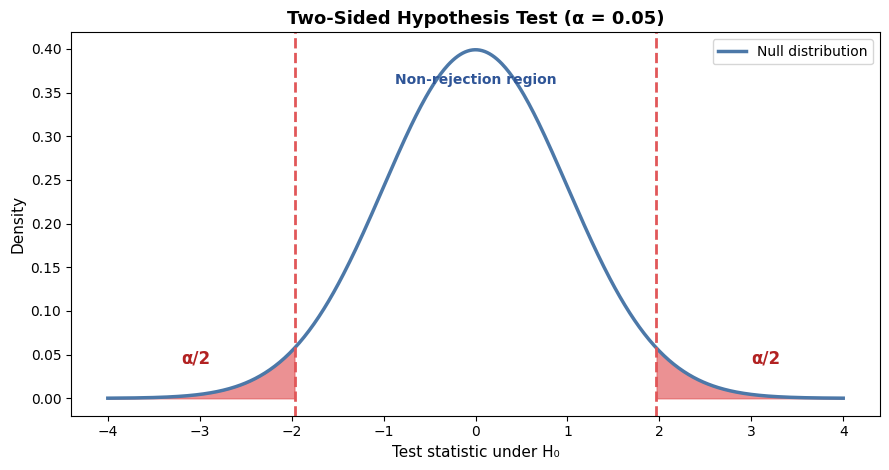

In [7]:
x = np.linspace(-4, 4, 600)
pdf = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x, pdf, color="#4C78A8", linewidth=2.5, label="Null distribution")

# Two-sided alpha = 0.05
crit = stats.norm.ppf(0.975)
left = x <= -crit
right = x >= crit

ax.fill_between(x[left], pdf[left], color="#E15759", alpha=0.65)
ax.fill_between(x[right], pdf[right], color="#E15759", alpha=0.65)

ax.axvline(-crit, color="#E15759", linestyle="--", linewidth=2)
ax.axvline(crit, color="#E15759", linestyle="--", linewidth=2)

ax.text(-3.2, 0.04, "α/2", color="#B22222", fontsize=12, fontweight="bold")
ax.text(3.0, 0.04, "α/2", color="#B22222", fontsize=12, fontweight="bold")
ax.text(0, 0.36, "Non-rejection region", ha="center", color="#2F5597", fontweight="bold")

ax.set_title("Two-Sided Hypothesis Test (α = 0.05)")
ax.set_xlabel("Test statistic under H₀")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Area merah di kedua ekor merupakan rejection regions yang total luasnya α = 0.05. Pada two-sided test, extreme results di kedua arah dianggap evidence against H₀.

## 7. Resampling — Permutation Test

Permutation test menguji apakah perbedaan antara dua kelompok dapat dijelaskan oleh random assignment.

Prosedurnya:

1. Gabungkan seluruh observasi.
2. Acak label group.
3. Hitung ulang statistic of interest.
4. Ulangi berkali-kali untuk membentuk null distribution.
5. Bandingkan observed statistic dengan null distribution.

Keunggulan pendekatan ini adalah tidak bergantung sepenuhnya pada asumsi distribusi parametrik.

In [8]:
# Simulasi "web stickiness": session duration pada dua group.
n_control = 100
n_treatment = 100

control = rng.normal(5.0, 1.1, n_control)
treatment = rng.normal(5.6, 1.1, n_treatment)

observed_diff = treatment.mean() - control.mean()

combined = np.concatenate([control, treatment])

permuted_diffs = np.empty(5000)

for i in range(len(permuted_diffs)):
    shuffled = rng.permutation(combined)
    perm_control = shuffled[:n_control]
    perm_treatment = shuffled[n_control:]
    permuted_diffs[i] = perm_treatment.mean() - perm_control.mean()

p_perm = np.mean(np.abs(permuted_diffs) >= abs(observed_diff))

print(f"Observed difference in means: {observed_diff:.4f}")
print(f"Permutation p-value: {p_perm:.4f}")

Observed difference in means: 0.8134
Permutation p-value: 0.0000


### Visualisasi 2 — Permutation Test: Web Stickiness

Chart ini dibuat dengan tiga visual cues:
- **abu-abu** = null distribution hasil permutation,
- **merah** = hasil yang sama ekstrem atau lebih ekstrem dari observed statistic,
- **biru** = observed difference.

Dengan demikian, p-value dapat dilihat langsung sebagai proporsi area ekstrem pada null distribution.

/opt/pyvenv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


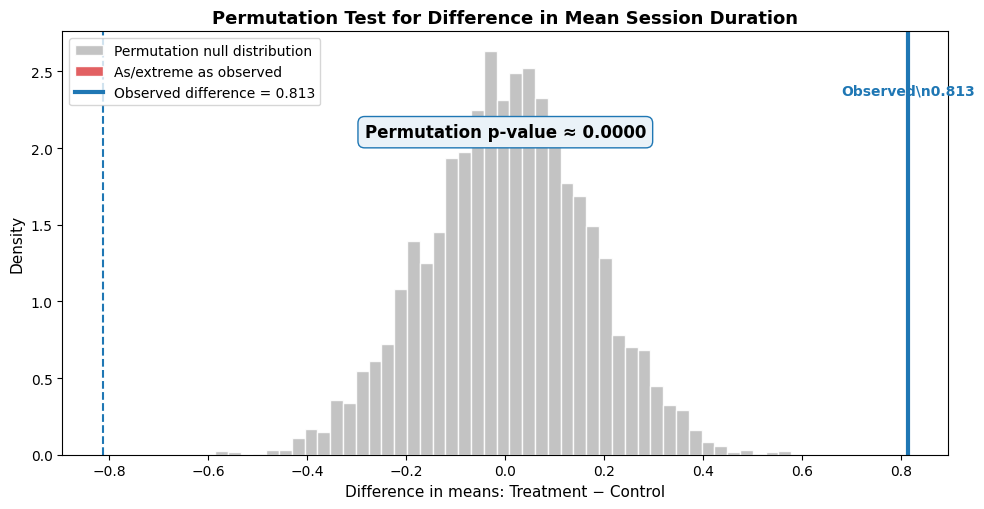

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.2))

ax.hist(
    permuted_diffs,
    bins=45,
    density=True,
    color="#BDBDBD",
    edgecolor="white",
    alpha=0.9,
    label="Permutation null distribution"
)

extreme = np.abs(permuted_diffs) >= abs(observed_diff)
ax.hist(
    permuted_diffs[extreme],
    bins=45,
    density=True,
    color="#E15759",
    edgecolor="white",
    alpha=0.95,
    label="As/extreme as observed"
)

ax.axvline(
    observed_diff,
    color="#1F77B4",
    linewidth=3,
    label=f"Observed difference = {observed_diff:.3f}"
)

ax.axvline(
    -observed_diff,
    color="#1F77B4",
    linewidth=1.5,
    linestyle="--"
)

ax.text(
    observed_diff,
    ax.get_ylim()[1] * 0.85,
    f"Observed\\n{observed_diff:.3f}",
    color="#1F77B4",
    fontweight="bold",
    ha="center"
)

ax.text(
    0,
    ax.get_ylim()[1] * 0.75,
    f"Permutation p-value ≈ {p_perm:.4f}",
    ha="center",
    fontsize=12,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#EAF2F8", edgecolor="#1F77B4")
)

ax.set_title("Permutation Test for Difference in Mean Session Duration")
ax.set_xlabel("Difference in means: Treatment − Control")
ax.set_ylabel("Density")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Null distribution berpusat di sekitar nol karena di bawah H₀ label treatment/control dianggap tidak memberikan perbedaan sistematis. Observed difference dibandingkan dengan distribution tersebut. Semakin jauh observed difference dari pusat null distribution, semakin kecil p-value.

## 8. Statistical Significance and p-Values

**p-value** adalah probability, dengan asumsi H₀ benar, untuk mendapatkan hasil setidaknya se-ekstrem observed result sesuai statistic dan arah test yang digunakan.

p-value **bukan** probabilitas bahwa H₀ benar.

Threshold yang umum digunakan adalah α = 0.05, tetapi nilai tersebut merupakan convention, bukan hukum universal.

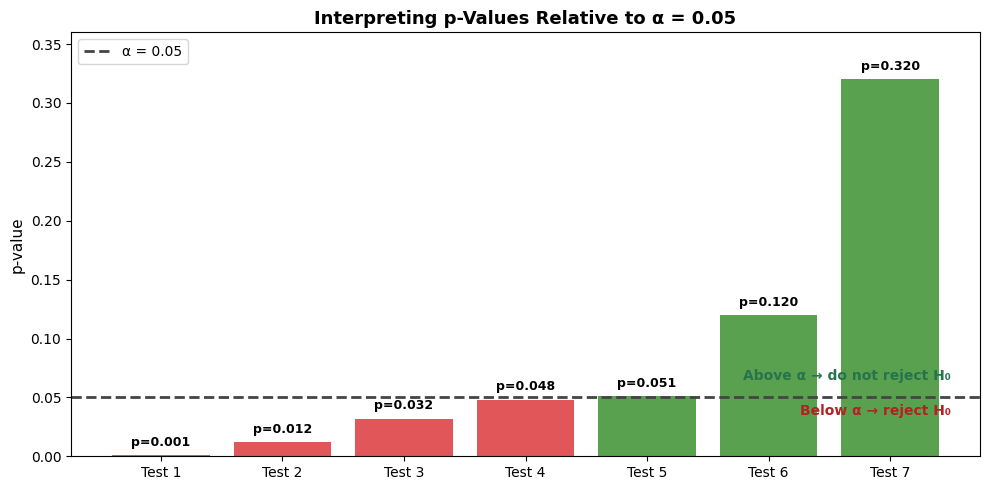

In [10]:
# Visualisasi hubungan p-value dan keputusan pada alpha = 0.05
p_values = np.array([0.001, 0.012, 0.032, 0.048, 0.051, 0.120, 0.320])
labels = [f"Test {i+1}" for i in range(len(p_values))]
significant = p_values < 0.05

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#E15759" if sig else "#59A14F" for sig in significant]
bars = ax.bar(labels, p_values, color=colors)

ax.axhline(
    0.05,
    color="#444444",
    linestyle="--",
    linewidth=2,
    label="α = 0.05"
)

for bar, p, sig in zip(bars, p_values, significant):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        p+0.008,
        f"p={p:.3f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.text(
    6.5, 0.035,
    "Below α → reject H₀",
    color="#B22222",
    fontweight="bold",
    ha="right"
)

ax.text(
    6.5, 0.065,
    "Above α → do not reject H₀",
    color="#26734D",
    fontweight="bold",
    ha="right"
)

ax.set_title("Interpreting p-Values Relative to α = 0.05")
ax.set_ylabel("p-value")
ax.set_ylim(0, 0.36)
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Bar merah menunjukkan p-value di bawah 0.05 sehingga, berdasarkan aturan keputusan yang dipilih, H₀ ditolak. Bar hijau berada di atas 0.05 sehingga hasilnya tidak cukup untuk menolak H₀. Warna hanya membantu membaca keputusan; statistical significance tetap ditentukan oleh perbandingan p-value dengan α.

## 9. Type 1 and Type 2 Errors

Dalam hypothesis testing terdapat dua jenis kesalahan:

- **Type I error:** menolak H₀ padahal H₀ benar. Probability yang dikendalikan oleh α.
- **Type II error:** gagal menolak H₀ padahal alternative hypothesis benar.

Keduanya berbeda dari practical significance. Hasil dapat statistically significant tetapi memiliki effect size yang sangat kecil dan tidak penting secara bisnis.

In [11]:
error_matrix = pd.DataFrame(
    [
        ["H₀ benar", "Reject H₀", "Type I error", "Correct"],
        ["H₀ salah", "Do not reject H₀", "Type II error", "Correct"],
    ],
    columns=["Reality", "Decision", "Error/Outcome", "Alternative"]
)

display(error_matrix)

,Reality,Decision,Error/Outcome,Alternative
0,H₀ benar,Reject H₀,Type I error,Correct
1,H₀ salah,Do not reject H₀,Type II error,Correct


### Visualisasi 3 — Type I dan Type II Error

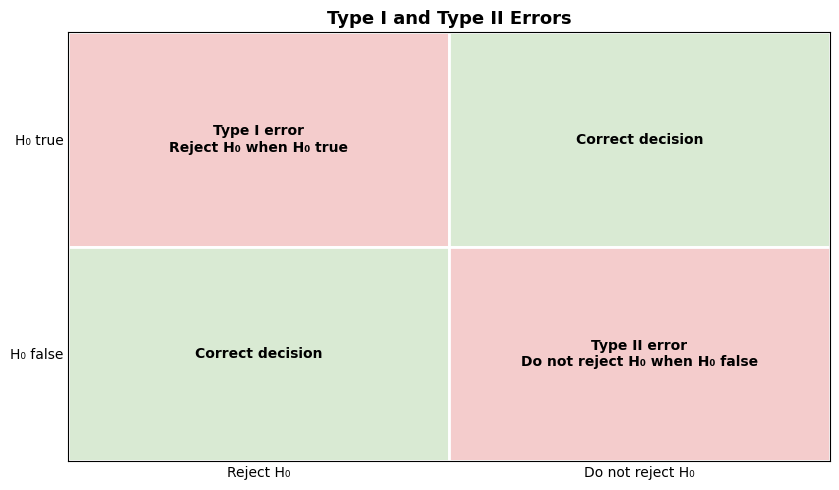

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5))

matrix = np.array([[1, 0], [0, 1]])

# Draw custom cells so meanings can be written directly.
cell_colors = [
    ["#F4CCCC", "#D9EAD3"],
    ["#D9EAD3", "#F4CCCC"]
]

for i in range(2):
    for j in range(2):
        rect = plt.Rectangle(
            (j, 1-i), 1, 1,
            facecolor=cell_colors[i][j],
            edgecolor="white",
            linewidth=2
        )
        ax.add_patch(rect)

texts = [
    ["Type I error\nReject H₀ when H₀ true", "Correct decision"],
    ["Correct decision", "Type II error\nDo not reject H₀ when H₀ false"]
]

for i in range(2):
    for j in range(2):
        ax.text(j+0.5, 1.5-i, texts[i][j], ha="center", va="center", fontweight="bold")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Reject H₀", "Do not reject H₀"])
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(["H₀ false", "H₀ true"])
ax.set_title("Type I and Type II Errors")
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Type I error terjadi ketika eksperimen menyatakan ada efek padahal sebenarnya tidak ada. Type II error terjadi ketika eksperimen gagal mendeteksi efek yang sebenarnya ada. Desain eksperimen perlu mempertimbangkan kedua risiko tersebut.

## 10. t-Tests

t-test digunakan untuk menguji perbedaan mean. Beberapa bentuk yang umum adalah:

- **One-sample t-test:** membandingkan sample mean dengan nilai hipotesis.
- **Two-sample t-test:** membandingkan mean dua kelompok.
- **Paired t-test:** membandingkan dua pengukuran yang berpasangan.

Untuk dua independent groups, Welch's t-test sering dipilih ketika asumsi equal variance tidak ingin dipaksakan.

In [13]:
t_stat, p_ttest = stats.ttest_ind(
    treatment,
    control,
    equal_var=False
)

print(f"Control mean   : {control.mean():.4f}")
print(f"Treatment mean : {treatment.mean():.4f}")
print(f"Difference     : {treatment.mean()-control.mean():.4f}")
print(f"t-statistic    : {t_stat:.4f}")
print(f"p-value        : {p_ttest:.6f}")

Control mean   : 4.7767
Treatment mean : 5.5901
Difference     : 0.8134
t-statistic    : 5.3186
p-value        : 0.000000


### Visualisasi 4 — Confidence Interval Dua Mean

Confidence interval membantu menunjukkan bukan hanya apakah mean berbeda, tetapi juga rentang ketidakpastian estimasinya. Jika interval untuk perbedaan mean tidak mencakup nol, hasil biasanya konsisten dengan statistical significance pada two-sided 5% test.

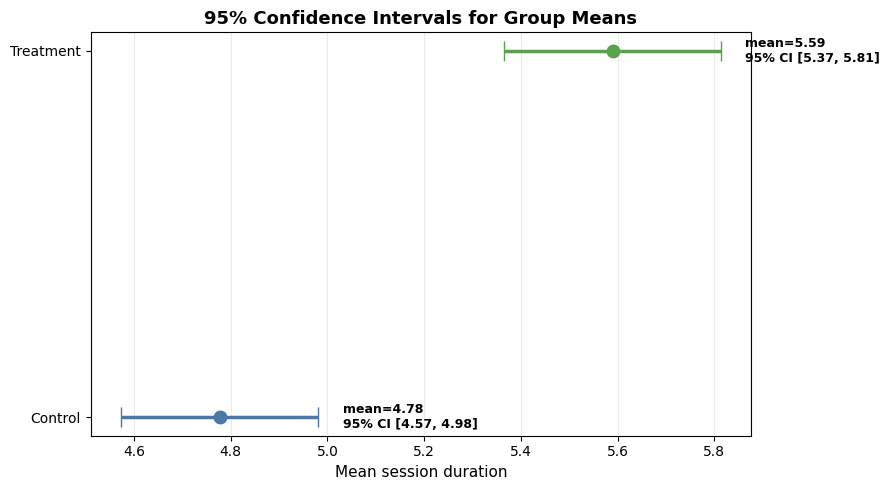

In [14]:
mean_control = control.mean()
mean_treatment = treatment.mean()

ci_control = stats.t.interval(
    0.95,
    len(control)-1,
    loc=mean_control,
    scale=stats.sem(control)
)

ci_treatment = stats.t.interval(
    0.95,
    len(treatment)-1,
    loc=mean_treatment,
    scale=stats.sem(treatment)
)

fig, ax = plt.subplots(figsize=(9, 5))

y = np.array([0, 1])
means = [mean_control, mean_treatment]
cis = [ci_control, ci_treatment]
colors = ["#4C78A8", "#59A14F"]

for yi, mean, ci, color, label in zip(y, means, cis, colors, ["Control", "Treatment"]):
    ax.errorbar(
        mean, yi,
        xerr=[[mean-ci[0]], [ci[1]-mean]],
        fmt="o",
        markersize=9,
        capsize=7,
        color=color,
        ecolor=color,
        linewidth=2.5
    )
    ax.text(
        ci[1] + 0.05,
        yi,
        f"mean={mean:.2f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_yticks(y)
ax.set_yticklabels(["Control", "Treatment"])
ax.set_xlabel("Mean session duration")
ax.set_title("95% Confidence Intervals for Group Means")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Titik menunjukkan mean dan horizontal error bars menunjukkan 95% confidence interval. Visualisasi ini membantu melihat magnitude dan uncertainty secara bersamaan, bukan hanya keputusan p-value.

## 11. Multiple Testing

Jika satu hypothesis test menggunakan α=0.05, probability Type I error relatif kecil. Namun jika banyak test dilakukan, probability mendapatkan setidaknya satu false positive meningkat.

Misalnya, jika `m` independent tests masing-masing menggunakan α, family-wise probability of at least one false positive secara sederhana dapat dihitung:

**1 − (1 − α)^m**

Ini menunjukkan alasan mengapa multiple comparisons memerlukan adjustment seperti Bonferroni atau metode false discovery rate.

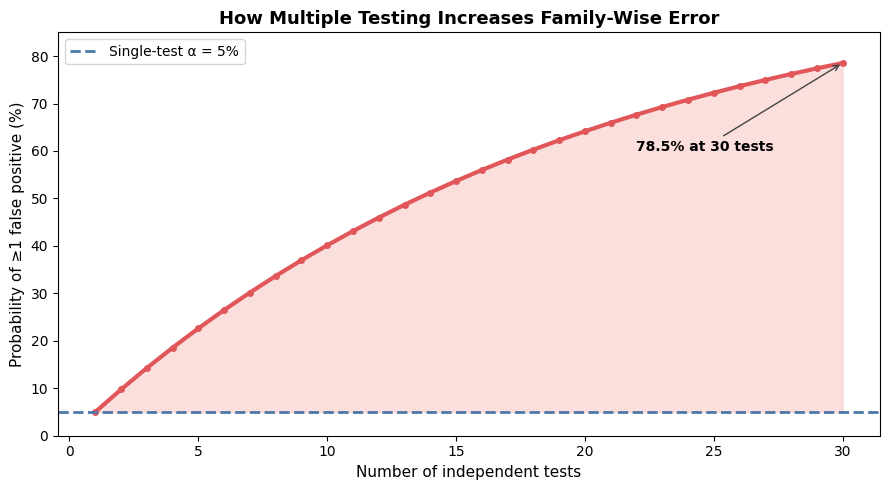

In [15]:
alpha = 0.05
m_values = np.arange(1, 31)
familywise_error = 1 - (1 - alpha) ** m_values

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    m_values,
    familywise_error * 100,
    color="#E15759",
    linewidth=3,
    marker="o",
    markersize=4
)

ax.axhline(
    5,
    color="#4C78A8",
    linestyle="--",
    linewidth=2,
    label="Single-test α = 5%"
)

ax.fill_between(
    m_values,
    5,
    familywise_error * 100,
    where=familywise_error*100 >= 5,
    color="#F8CECC",
    alpha=0.65
)

ax.set_title("How Multiple Testing Increases Family-Wise Error")
ax.set_xlabel("Number of independent tests")
ax.set_ylabel("Probability of ≥1 false positive (%)")
ax.set_ylim(0, 85)
ax.legend()

ax.annotate(
    f"{familywise_error[-1]*100:.1f}% at 30 tests",
    xy=(30, familywise_error[-1]*100),
    xytext=(22, 60),
    arrowprops=dict(arrowstyle="->", color="#444444"),
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Ketika jumlah independent tests meningkat, probability mendapatkan setidaknya satu false positive juga meningkat. Ini bukan berarti semua multiple tests salah, tetapi menunjukkan mengapa hasil dari banyak pengujian perlu ditafsirkan dengan correction atau error-control strategy yang sesuai.

## 12. Degrees of Freedom

Degrees of freedom (df) menggambarkan jumlah informasi yang secara efektif tersedia untuk mengestimasi parameter setelah constraints diperhitungkan.

Pada one-sample t-test sederhana:

**df = n − 1**

Degrees of freedom memengaruhi bentuk t-distribution dan critical values. Sample kecil menghasilkan df kecil dan tail yang lebih berat.

In [16]:
df_values = np.array([2, 5, 10, 30])
critical_values = stats.t.ppf(0.975, df_values)

df_table = pd.DataFrame({
    "Degrees of freedom": df_values,
    "Two-sided 95% critical value": critical_values
})

display(df_table)

,Degrees of freedom,Two-sided 95% critical value
0,2,4.302653
1,5,2.570582
2,10,2.228139
3,30,2.042272


### Visualisasi 5 — Dampak Degrees of Freedom pada t-Distribution

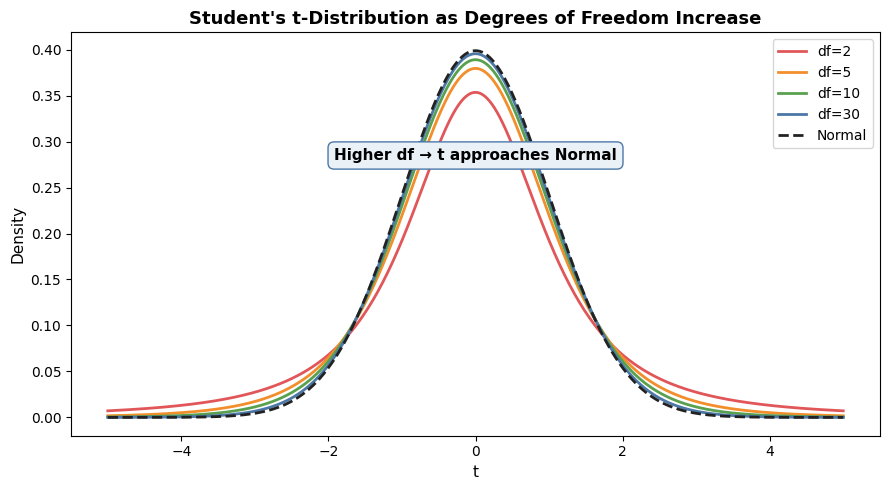

In [17]:
x = np.linspace(-5, 5, 600)

fig, ax = plt.subplots(figsize=(9, 5))

for df, color in zip([2, 5, 10, 30], ["#E15759", "#F28E2B", "#59A14F", "#4C78A8"]):
    ax.plot(
        x,
        stats.t.pdf(x, df),
        color=color,
        linewidth=2,
        label=f"df={df}"
    )

ax.plot(
    x,
    stats.norm.pdf(x),
    color="#222222",
    linestyle="--",
    linewidth=2,
    label="Normal"
)

ax.set_title("Student's t-Distribution as Degrees of Freedom Increase")
ax.set_xlabel("t")
ax.set_ylabel("Density")
ax.legend()

ax.text(
    0, 0.28,
    "Higher df → t approaches Normal",
    ha="center",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#EAF2F8", edgecolor="#4C78A8")
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** df rendah menghasilkan tail yang lebih berat, sehingga critical values lebih ekstrem. Ketika df meningkat, t-distribution semakin mendekati normal distribution.

## 13. ANOVA F-Statistic

**ANOVA (Analysis of Variance)** digunakan untuk menguji apakah terdapat perbedaan mean di antara lebih dari dua kelompok.

Hipotesis:

- H₀: semua group means sama.
- H₁: setidaknya ada satu group mean yang berbeda.

F-statistic membandingkan variability **between groups** dengan variability **within groups**:

**F = MS_between / MS_within**

Jika between-group variability jauh lebih besar dibandingkan within-group variability, F menjadi besar.

In [18]:
group_A = rng.normal(10.0, 1.0, 40)
group_B = rng.normal(10.8, 1.0, 40)
group_C = rng.normal(11.3, 1.0, 40)

f_stat, p_anova = stats.f_oneway(group_A, group_B, group_C)

anova_summary = pd.DataFrame({
    "Group": ["A", "B", "C"],
    "Mean": [group_A.mean(), group_B.mean(), group_C.mean()],
    "SD": [group_A.std(ddof=1), group_B.std(ddof=1), group_C.std(ddof=1)]
})

display(anova_summary)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value    : {p_anova:.6f}")

,Group,Mean,SD
0,A,10.024911,1.049197
1,B,10.989473,0.932285
2,C,11.625958,1.322130


F-statistic: 20.9728
p-value    : 0.000000


### Visualisasi 6 — ANOVA: Distribution Across Groups

/tmp/ipykernel_1636/1106939423.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


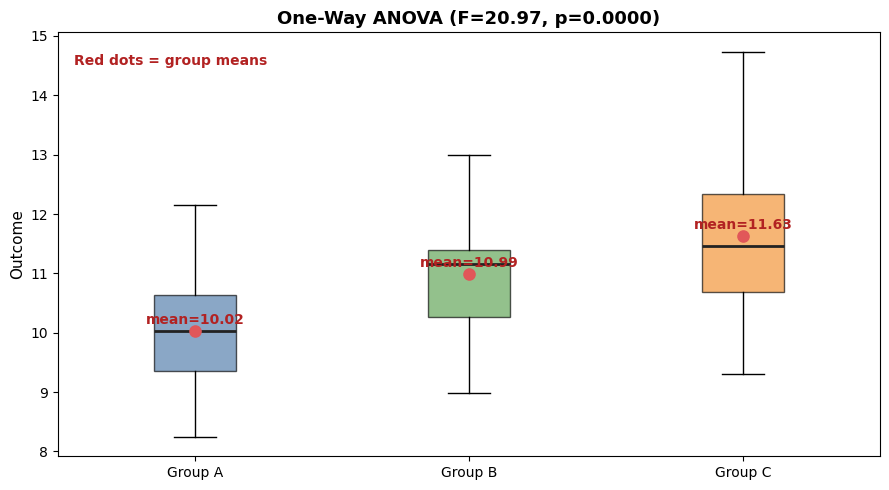

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

data_groups = [group_A, group_B, group_C]
labels = ["Group A", "Group B", "Group C"]

bp = ax.boxplot(
    data_groups,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color="#222222", linewidth=2)
)

box_colors = ["#4C78A8", "#59A14F", "#F28E2B"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

means = [g.mean() for g in data_groups]

for i, mean in enumerate(means, start=1):
    ax.scatter(i, mean, color="#E15759", s=65, zorder=4)
    ax.text(
        i,
        mean + 0.12,
        f"mean={mean:.2f}",
        ha="center",
        color="#B22222",
        fontweight="bold"
    )

ax.set_title(f"One-Way ANOVA (F={f_stat:.2f}, p={p_anova:.4f})")
ax.set_ylabel("Outcome")
ax.text(
    0.02, 0.95,
    "Red dots = group means",
    transform=ax.transAxes,
    va="top",
    color="#B22222",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Boxplot memperlihatkan distribusi setiap group, sedangkan titik merah menandai group mean. ANOVA menguji perbedaan mean secara keseluruhan; jika signifikan, analisis lanjutan diperlukan untuk mengetahui pasangan group mana yang berbeda.

## 14. Two-Way ANOVA

Two-way ANOVA memperluas ANOVA dengan dua factor. Analisis ini dapat menguji:

1. Main effect factor A.
2. Main effect factor B.
3. Interaction effect A × B.

Interaction berarti efek satu factor berubah bergantung pada level factor lainnya.

In [20]:
# Simulasi dua faktor: Design dan Device
rows = []

for design in ["A", "B"]:
    for device in ["Mobile", "Desktop"]:
        base = 10 if design == "A" else 11
        device_effect = 1.0 if device == "Desktop" else 0
        interaction = 1.0 if design == "B" and device == "Mobile" else 0
        values = rng.normal(base + device_effect + interaction, 0.8, 30)

        for value in values:
            rows.append([design, device, value])

two_way = pd.DataFrame(rows, columns=["Design", "Device", "Outcome"])

summary_two_way = (
    two_way.groupby(["Design", "Device"])["Outcome"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

display(summary_two_way)

,Design,Device,mean,std,count
0,A,Desktop,11.038555,0.612294,30
1,A,Mobile,9.957887,0.806483,30
2,B,Desktop,12.060920,0.699675,30
3,B,Mobile,11.870556,0.638087,30


### Visualisasi 7 — Interaction Plot

Interaction plot digunakan untuk melihat apakah garis antar-level factor cenderung paralel atau tidak. Garis yang tidak paralel dapat menjadi indikasi visual adanya interaction effect.

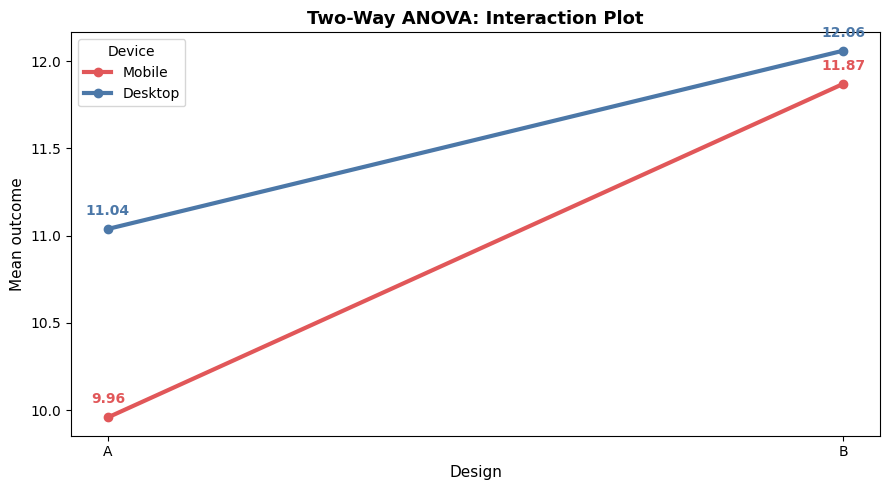

In [21]:
means_two_way = (
    two_way.groupby(["Design", "Device"])["Outcome"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    means_two_way.index,
    means_two_way["Mobile"],
    marker="o",
    linewidth=3,
    color="#E15759",
    label="Mobile"
)

ax.plot(
    means_two_way.index,
    means_two_way["Desktop"],
    marker="o",
    linewidth=3,
    color="#4C78A8",
    label="Desktop"
)

for device, color in [("Mobile", "#E15759"), ("Desktop", "#4C78A8")]:
    for design, value in means_two_way[device].items():
        ax.text(
            design,
            value + 0.08,
            f"{value:.2f}",
            color=color,
            ha="center",
            fontweight="bold"
        )

ax.set_title("Two-Way ANOVA: Interaction Plot")
ax.set_xlabel("Design")
ax.set_ylabel("Mean outcome")
ax.legend(title="Device")

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Garis Mobile dan Desktop menunjukkan mean outcome pada setiap design. Jika perubahan dari A ke B berbeda antar-device, pola non-paralel dapat mengindikasikan interaction yang perlu diuji secara formal.

## 15. Chi-Square Test

Chi-square test digunakan untuk data kategorikal, khususnya untuk menguji apakah dua categorical variables memiliki association.

Contoh:

- H₀: device dan conversion status independent.
- H₁: device dan conversion status associated.

Test statistic membandingkan observed counts dengan expected counts yang akan muncul jika kedua variable independent.

In [22]:
observed = np.array([
    [850, 150],   # Mobile: no, yes
    [760, 240]    # Desktop: no, yes
])

chi2, p_chi, dof, expected = stats.chi2_contingency(observed)

expected_table = pd.DataFrame(
    expected,
    index=["Mobile", "Desktop"],
    columns=["No conversion", "Conversion"]
)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom : {dof}")
print(f"p-value             : {p_chi:.6f}")

display(expected_table)

Chi-square statistic: 25.2301
Degrees of freedom : 1
p-value             : 0.000001


,No conversion,Conversion
Mobile,805.0,195.0
Desktop,805.0,195.0


### Visualisasi 8 — Observed vs Expected Counts

Membandingkan observed dan expected counts membantu menjelaskan apa yang sebenarnya diuji oleh chi-square test.

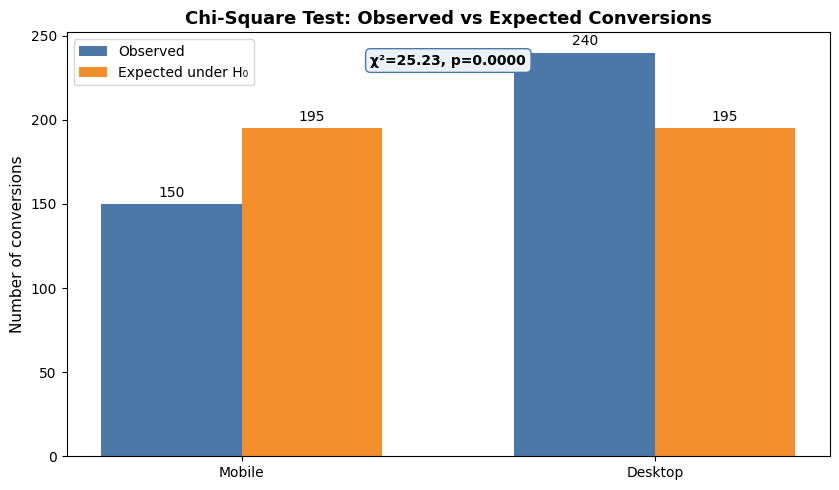

In [23]:
categories = ["Mobile", "Desktop"]
observed_yes = observed[:, 1]
expected_yes = expected[:, 1]

x = np.arange(len(categories))
width = 0.34

fig, ax = plt.subplots(figsize=(8.5, 5))

bars1 = ax.bar(
    x - width/2,
    observed_yes,
    width,
    label="Observed",
    color="#4C78A8"
)

bars2 = ax.bar(
    x + width/2,
    expected_yes,
    width,
    label="Expected under H₀",
    color="#F28E2B"
)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Number of conversions")
ax.set_title("Chi-Square Test: Observed vs Expected Conversions")
ax.legend()

for bars in [bars1, bars2]:
    ax.bar_label(bars, fmt="%.0f", padding=3)

ax.text(
    0.5, 0.95,
    f"χ²={chi2:.2f}, p={p_chi:.4f}",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#EAF2F8", edgecolor="#4C78A8")
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Bar biru menunjukkan observed conversions, sedangkan orange menunjukkan jumlah yang diharapkan jika device dan conversion independent. Semakin besar perbedaan observed dan expected secara keseluruhan, semakin besar chi-square statistic.

## 16. Fisher's Exact Test

Fisher's exact test digunakan untuk contingency table kecil, terutama ketika expected cell counts terlalu rendah untuk pendekatan chi-square yang nyaman.

Berbeda dengan chi-square approximation, Fisher's exact test menghitung probability berdasarkan distribusi tabel secara exact untuk kondisi yang diberikan.

In [24]:
small_table = np.array([
    [8, 2],
    [3, 7]
])

odds_ratio, p_fisher = stats.fisher_exact(small_table)

print("Odds ratio:", odds_ratio)
print("Fisher exact p-value:", p_fisher)

Odds ratio: 9.333333333333334
Fisher exact p-value: 0.06977851869492736


**Interpretasi:** Fisher's exact test cocok ketika sample atau cell count kecil. Hasilnya digunakan untuk mengevaluasi association antara dua categorical variables tanpa mengandalkan large-sample chi-square approximation.

## 17. Relevance for Data Science

Statistical significance memiliki beberapa keterbatasan dalam konteks data science.

1. **Significant ≠ practically important.** Efek sangat kecil dapat signifikan jika sample sangat besar.
2. **Non-significant ≠ no effect.** Bisa saja sample terlalu kecil sehingga power rendah.
3. **Repeated testing** meningkatkan false positive.
4. **Experiment design** harus dibuat sebelum melihat hasil.
5. **Effect size dan confidence interval** perlu dilaporkan bersama p-value.
6. Pada produk digital, keputusan akhir juga harus mempertimbangkan cost, user impact, latency, revenue, dan operational constraints.

## 18. Multi-Arm Bandit Algorithm

Multi-arm bandit merupakan pendekatan sequential decision-making yang menyeimbangkan:

- **Exploration:** mencoba arm untuk memperoleh informasi.
- **Exploitation:** menggunakan arm yang saat ini terlihat memberikan reward terbaik.

Berbeda dengan fixed A/B testing, bandit dapat mengubah alokasi traffic selama eksperimen berjalan.

In [25]:
# Simulasi sederhana epsilon-greedy.
true_rates = np.array([0.08, 0.10, 0.12])
n_rounds = 3000
epsilon = 0.10

estimated_rates = np.zeros(3)
counts = np.zeros(3)

rewards = []
chosen_arms = []

for _ in range(n_rounds):
    if rng.random() < epsilon or np.all(counts == 0):
        arm = rng.integers(0, 3)
    else:
        arm = np.argmax(estimated_rates)

    reward = rng.binomial(1, true_rates[arm])

    counts[arm] += 1
    estimated_rates[arm] += (reward - estimated_rates[arm]) / counts[arm]

    rewards.append(reward)
    chosen_arms.append(arm)

bandit_summary = pd.DataFrame({
    "Arm": ["A", "B", "C"],
    "True conversion": true_rates,
    "Estimated conversion": estimated_rates,
    "Selections": counts.astype(int)
})

display(bandit_summary)

,Arm,True conversion,Estimated conversion,Selections
0,A,0.08,0.046296,108
1,B,0.10,0.051020,98
2,C,0.12,0.114173,2794


### Visualisasi 9 — Exploration vs Exploitation

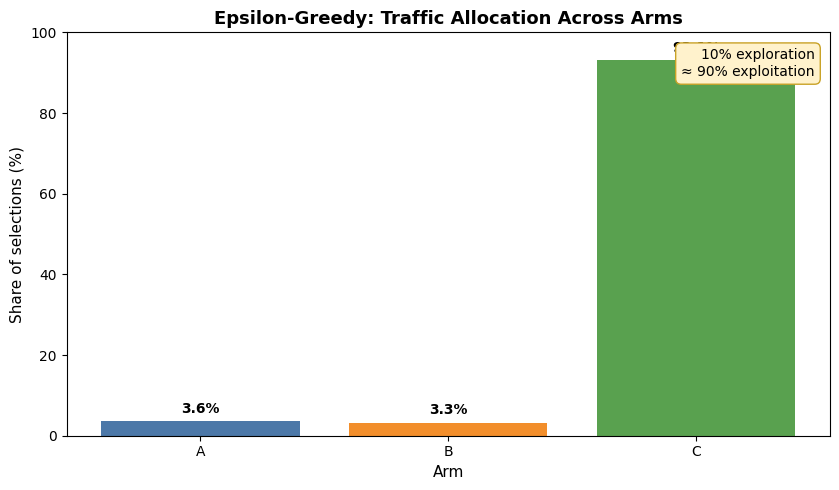

In [26]:
selection_share = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8.5, 5))

bars = ax.bar(
    ["A", "B", "C"],
    selection_share,
    color=["#4C78A8", "#F28E2B", "#59A14F"]
)

ax.set_title("Epsilon-Greedy: Traffic Allocation Across Arms")
ax.set_xlabel("Arm")
ax.set_ylabel("Share of selections (%)")
ax.set_ylim(0, 100)

for bar, share in zip(bars, selection_share):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        share+2,
        f"{share:.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.text(
    0.98, 0.96,
    "10% exploration\n≈ 90% exploitation",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF2CC", edgecolor="#C9A227")
)

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Algoritma epsilon-greedy tetap melakukan exploration, tetapi sebagian besar keputusan setelah informasi terkumpul diarahkan ke arm dengan estimated reward lebih tinggi. Ini menggambarkan trade-off antara memperoleh informasi baru dan memanfaatkan pilihan yang sudah terlihat baik.

## 19. Power and Sample Size

**Statistical power** adalah probability untuk mendeteksi effect yang benar-benar ada, dengan asumsi effect tersebut sesuai dengan alternatif yang ditentukan.

Secara umum power meningkat ketika:

- sample size meningkat,
- effect size meningkat,
- variability menurun,
- alpha dinaikkan.

Power analysis penting sebelum eksperimen agar sample size tidak terlalu kecil sehingga eksperimen sulit mendeteksi effect yang relevan.

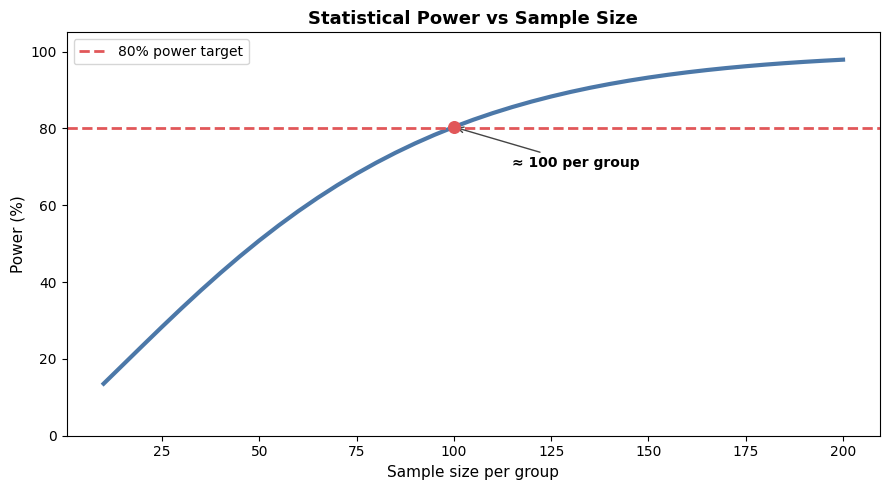

In [27]:
# Power two-sample t-test sebagai fungsi sample size.
effect_size = 0.4
alpha = 0.05

sample_sizes_power = np.arange(10, 201, 5)
powers = []

for n in sample_sizes_power:
    # Noncentral t approximation for two independent groups.
    df = 2*n - 2
    delta = effect_size / np.sqrt(2/n)
    critical = stats.t.ppf(1 - alpha/2, df)
    power = (
        1 - stats.nct.cdf(critical, df, delta)
        + stats.nct.cdf(-critical, df, delta)
    )
    powers.append(power)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    sample_sizes_power,
    np.array(powers)*100,
    color="#4C78A8",
    linewidth=3
)

ax.axhline(
    80,
    color="#E15759",
    linestyle="--",
    linewidth=2,
    label="80% power target"
)

idx = np.where(np.array(powers) >= 0.80)[0]
if len(idx):
    n80 = sample_sizes_power[idx[0]]
    ax.scatter(n80, powers[idx[0]]*100, color="#E15759", s=70, zorder=4)
    ax.annotate(
        f"≈ {n80} per group",
        xy=(n80, powers[idx[0]]*100),
        xytext=(n80+15, 70),
        arrowprops=dict(arrowstyle="->", color="#444444"),
        fontweight="bold"
    )

ax.set_title("Statistical Power vs Sample Size")
ax.set_xlabel("Sample size per group")
ax.set_ylabel("Power (%)")
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()

**Caption / Penjelasan Chart:** Power meningkat seiring sample size. Garis merah menunjukkan target ilustratif 80%. Titik yang diberi anotasi menunjukkan perkiraan sample size per group yang dibutuhkan untuk mencapai target tersebut pada effect size dan alpha yang digunakan dalam simulasi.

## 20. Practical Significance vs Statistical Significance

Statistical significance menjawab pertanyaan apakah data memberikan evidence yang cukup terhadap H₀ menurut prosedur test.

Practical significance menjawab pertanyaan yang berbeda: **apakah besarnya effect cukup penting untuk keputusan nyata?**

Contoh: peningkatan conversion dari 10.0000% menjadi 10.0005% dapat menjadi statistically significant pada sample yang sangat besar, tetapi dampak bisnisnya mungkin kecil.

Karena itu, analisis eksperimen sebaiknya melaporkan:
- effect size,
- confidence interval,
- p-value,
- sample size,
- dan konteks keputusan.

In [28]:
# Ilustrasi: effect size kecil vs besar
effects = pd.DataFrame({
    "Scenario": ["Very small effect", "Moderate effect"],
    "Absolute lift (pp)": [0.05, 1.50],
    "Business interpretation": [
        "May be statistically detectable",
        "Potentially more operationally meaningful"
    ]
})

display(effects)

,Scenario,Absolute lift (pp),Business interpretation
0,Very small effect,0.05,May be statistically detectable
1,Moderate effect,1.50,Potentially more operationally meaningful


## 21. Kesimpulan Chapter

Chapter 3 menunjukkan bahwa eksperimen statistik bukan sekadar menghitung p-value. Proses yang benar dimulai dari desain eksperimen, penentuan control, formulasi hipotesis, pemilihan test atau resampling method, lalu interpretasi uncertainty dan effect size.

### Ringkasan Konsep

| Konsep | Inti Pemahaman |
|---|---|
| A/B testing | Membandingkan dua kondisi secara terkontrol |
| Control group | Memberikan baseline untuk comparison |
| Hypothesis test | Mengevaluasi evidence terhadap H₀ |
| Permutation test | Membentuk null distribution melalui label shuffling |
| p-value | Probability mendapatkan hasil setidaknya se-ekstrem observed result jika H₀ benar |
| Alpha | Threshold keputusan yang ditentukan sebelum testing |
| Type I error | False positive |
| Type II error | False negative |
| t-test | Pengujian perbedaan mean |
| Multiple testing | Banyak test meningkatkan risiko false positive |
| Degrees of freedom | Mengontrol bentuk distribution test statistic |
| ANOVA | Menguji mean lebih dari dua group |
| Chi-square | Menguji association categorical variables |
| Fisher's exact | Exact test untuk contingency table kecil |
| Multi-arm bandit | Menyeimbangkan exploration dan exploitation |
| Power | Probability mendeteksi effect yang benar-benar ada |

### Hubungan dengan ML/DL

Dalam Machine Learning dan Deep Learning, konsep eksperimen digunakan untuk membandingkan model, hyperparameter, feature engineering, dan deployment variants. Prinsip yang sama tetap berlaku: perbandingan harus memiliki baseline yang jelas, evaluasi harus mempertimbangkan variability, dan hasil yang “significant” secara statistik belum tentu paling relevan secara praktis.

## 22. Referensi

1. Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python* (2nd ed.). O'Reilly Media.
2. O'Reilly — Chapter 3: *Statistical Experiments and Significance Testing*.
3. Gedeck, P. et al. — official Python code repository for *Practical Statistics for Data Scientists*.

**Catatan akademik:** Struktur notebook mengikuti topik Chapter 3 pada edisi kedua. Kode simulasi ditulis ulang untuk reproduksi pembelajaran, sedangkan angka yang dibuat melalui simulasi diberi konteks sebagai data ilustratif/synthetic sehingga tidak disalahartikan sebagai data empiris buku.